## 패키지 선언

In [1]:
import torch
import torch.nn as nn
import numpy as np
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader


## Dataset 선언

In [2]:
# Training dataset 다운로드
cifar10_train = dataset.CIFAR10(root = "./", # 데이터셋을 저장할 위치
                            train = True,
                            transform = transform.ToTensor(),
                            download = True)
# Testing dataset 다운로드
cifar10_test = dataset.CIFAR10(root = "./",
                            train = False,
                            transform = transform.ToTensor(),
                            download = True)

100%|██████████| 170498071/170498071 [00:08<00:00, 19925109.32it/s]


Extracting ./cifar-10-python.tar.gz to ./
Files already downloaded and verified


## CIFAR10 데이터셋 형상 확인

50000
torch.Size([3, 32, 32])
9


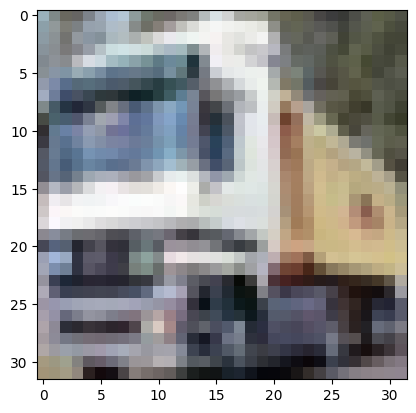

In [3]:
from matplotlib import pyplot as plt
print(len(cifar10_train))     # training dataset 개수 확인

first_data = cifar10_train[1]
print(first_data[0].shape)  # 두번째 data의 형상 확인
print(first_data[1])        # 두번째 data의 정답 확인


plt.imshow(first_data[0].permute(1, 2, 0))
plt.show()

## Skip, Dense Connection, Channel Attention 조합실험

In [4]:
class ResNet (nn.Module):
  def __init__ (self):
    super(ResNet, self).__init__()

    self.conv1_1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
    self.conv1_2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

    self.conv2_1 = nn.Conv2d(in_channels=35, out_channels=32, kernel_size=3, padding=1)
    self.conv2_2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

    self.conv3_1 = nn.Conv2d(in_channels=99, out_channels=128, kernel_size=3, padding=1)
    self.conv3_2 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)

    self.fc1 = nn.Linear(4096, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 10)

    # Channel Attention 을 위한 convolution layer 선언

    self.GAP = nn.AdaptiveAvgPool2d((1, 1)) #들어오는 크기만큼 풀링을 해주겠다
    self.conv_CA1= nn.Conv2d(in_channels = 64, out_channels = 64, kernel_size = 1)
    self.conv_CA2= nn.Conv2d(in_channels = 64, out_channels = 64, kernel_size = 1)
    self.sigmoid = nn.Sigmoid()

    # Skip connection을 위한 convolution layer 선언
    self.conv_skip1 = nn.Conv2d(in_channels = 3,out_channels = 32, kernel_size = 3, padding = 1)
    self.conv_skip2 = nn.Conv2d(in_channels = 35,out_channels = 64, kernel_size = 3, padding = 1)
    self.conv_skip3 = nn.Conv2d(in_channels = 99,out_channels = 256, kernel_size = 3, padding = 1)

    # 파라미터를 가지지 않은 layer는 한 번만 선언해도 문제 없음
    self.relu = nn.ReLU()
    self.maxPool2d = nn.MaxPool2d(kernel_size=2, stride=2)


  def forward(self, x):

    # convolution layers
    skip = self.relu(self.conv_skip1(x))
    out = self.relu(self.conv1_1(x))
    out = self.relu(self.conv1_2(out))
    out2 = out + skip # 처음 정보를 잃지 않기 위해 계속해서 더해준다
    out = torch.cat([x, out2], dim = 1)
    max_pool = self.maxPool2d(out)


    skip= self.relu(self.conv_skip2(max_pool))
    out = self.relu(self.conv2_1(max_pool))
    out = self.relu(self.conv2_2(out))

    weight = self.GAP(out) # 전체를 풀링해서 1*1*C를 만든다
    weight = self.relu(self.conv_CA1(weight)) # relu 함수 적용시키고
    weight = self.conv_CA2(weight) # 나온 weight 값을 conv_CA2에 곱해주고
    weight = self.sigmoid(weight) # sigmoid 함수 적용

    out = out * weight # 나온 weight 값을 out에 곱해준다
    out3 = out + skip
    out = torch.cat([max_pool, out3], dim = 1)
    out = self.maxPool2d(out)


    skip = self.relu(self.conv_skip3(out))
    out = self.relu(self.conv3_1(out))
    out = self.relu(self.conv3_2(out))
    out = out + skip
    out = self.maxPool2d(out)

    # 평탄화
    out = out.reshape(-1, 4096)

    # fully connected layers
    out = self.relu(self.fc1(out))
    out = self.relu(self.fc2(out))
    out = self.fc3(out)

    return out

## ResNet 조합실험

In [5]:
class ResNet (nn.Module):
  def __init__ (self):
    super(ResNet, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)

    self.resdual1_1 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
    self.resdual1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
    self.resdual1_3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
    self.resdual1_4 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
    self.resdual1_5 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
    self.resdual1_6 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)

    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

    self.resdual2_1 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
    self.resdual2_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
    self.resdual2_3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
    self.resdual2_4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
    self.resdual2_5 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
    self.resdual2_6 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

    self.conv3 = nn.Conv2d(in_channels=64, out_channels=4, kernel_size=3, padding=1)

    self.fc1 = nn.Linear(4096, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 10)

    # 파라미터를 가지지 않은 layer는 한 번만 선언해도 문제 없음
    self.relu = nn.ReLU()

  def forward(self, x):

    # convolution layers
    skip = self.relu(self.conv1(x))

    out = self.relu(self.resdual1_1(skip))
    out = self.relu(self.resdual1_2(out))

    skip = out + skip

    out = self.relu(self.resdual1_3(skip))
    out = self.relu(self.resdual1_4(out))

    skip = out + skip

    out = self.relu(self.resdual1_5(skip))
    out = self.relu(self.resdual1_6(out))

    out = out + skip

    skip = self.relu(self.conv2(out))

    out = self.relu(self.resdual2_1(skip))
    out = self.relu(self.resdual2_2(out))

    skip = out + skip

    out = self.relu(self.resdual2_3(skip))
    out = self.relu(self.resdual2_4(out))

    skip = out + skip

    out = self.relu(self.resdual2_5(skip))
    out = self.relu(self.resdual2_6(out))

    out = out + skip

    out = self.relu(self.conv3(out))

    # 평탄화
    out = out.reshape(-1, 4096)

    # fully connected layers
    out = self.relu(self.fc1(out))
    out = self.relu(self.fc2(out))
    out = self.fc3(out)

    return out

## Hyper-parameters 지정

In [6]:
batch_size = 100
learning_rate = 0.1
training_epochs = 20
loss_function = nn.CrossEntropyLoss()
network = ResNet()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)
data_loader = DataLoader(dataset=cifar10_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perceptron 학습을 위한 반복문 선언

In [7]:
network = network.to('cuda:0')
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    img = img.to('cuda:0')
    label = label.to('cuda:0')

    pred = network(img)

    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    loss.backward()
    optimizer.step()

    avg_cost += loss / total_batch

  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))

print('Learning finished')

Epoch: 1 Loss = 2.066473
Epoch: 2 Loss = 1.676806
Epoch: 3 Loss = 1.474133
Epoch: 4 Loss = 1.337113
Epoch: 5 Loss = 1.212848
Epoch: 6 Loss = 1.079201
Epoch: 7 Loss = 0.941137
Epoch: 8 Loss = 0.779306
Epoch: 9 Loss = 0.615408
Epoch: 10 Loss = 0.457903
Epoch: 11 Loss = 0.331859
Epoch: 12 Loss = 0.247543
Epoch: 13 Loss = 0.170257
Epoch: 14 Loss = 0.149798
Epoch: 15 Loss = 0.117541
Epoch: 16 Loss = 0.092956
Epoch: 17 Loss = 0.078859
Epoch: 18 Loss = 0.062397
Epoch: 19 Loss = 0.057377
Epoch: 20 Loss = 0.054556
Learning finished


## 학습이 완료된 모델을 이용해 정답률 확인

In [8]:
network = network.to('cpu')
with torch.no_grad(): # test에서는 기울기 계산 제외

  img_test = torch.tensor(np.transpose(cifar10_test.data, (0, 3, 1, 2)))/255.
  label_test = torch.tensor(cifar10_test.targets)

  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.551800012588501
